In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: seefood/test/hot_dog/133012.jpg  
  inflating: seefood/test/hot_dog/133015.jpg  
  inflating: seefood/test/hot_dog/133245.jpg  
  inflating: seefood/test/hot_dog/135628.jpg  
  inflating: seefood/test/hot_dog/138933.jpg  
  inflating: seefood/test/hot_dog/138937.jpg  
  inflating: seefood/test/hot_dog/138969.jpg  
  inflating: seefood/test/hot_dog/139177.jpg  
  inflating: seefood/test/hot_dog/142835.jpg  
  inflating: seefood/test/hot_dog/143012.jpg  
  inflating: seefood/test/hot_dog/144956.jpg  
  inflating: seefood/test/hot_dog/146227.jpg  
  inflating: seefood/test/hot_dog/146834.jpg  
  inflating: seefood/test/hot_dog/147874.jpg  
  inflating: seefood/test/hot_dog/152106.jpg  
  inflating: seefood/test/hot_dog/154409.jpg  
  inflating: seefood/test/hot_dog/154545.jpg  
  inflating: seefood/test/hot_dog/156126.jpg  
  inflating: seefood/test/hot_dog/156135.jpg  
  inflating: seefood/test/hot_dog/160274.jpg  
  inflating: seefood/test/hot_dog/1605

In [ ]:
# Define paths (CHANGE THIS to your actual path)
train_path = "/content/train"
test_path = "/content/test"

# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))
print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# Count and print test images
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Test hot dog images: {test_hot_dog_count}")
print(f"Test not hot dog images: {test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250


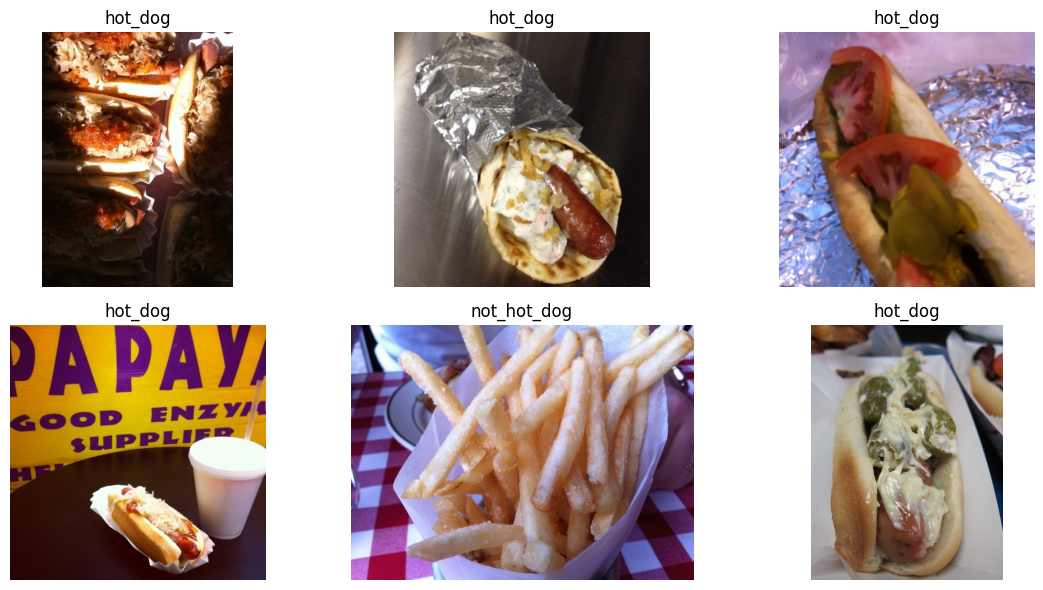

Image shape: (512, 384, 3)
Height: 512, Width: 384, Channels: 3


In [35]:
# Display 6 random images
plt.figure(figsize=(12, 6))
for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print the shape of the last loaded image
print(f"Image shape: {img.shape}")
print(f"Height: {img.shape[0]}, Width: {img.shape[1]}, Channels: {img.shape[2]}")

In [34]:
# Set image size (YOUR CHOICE: 64x64 is faster, 128x128 is more accurate)
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values from 0-255 to 0-1
    validation_split=0.2   # Use 20% of training data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',   # Binary classification (hot dog vs not)
    subset='training'      # Training set (80% of data)
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'    # Validation set (20% of data)
)

# Print the class labels
print(f"Class labels: {train_generator.class_indices}")
print(f"Class 0 = {list(train_generator.class_indices.keys())[0]}")
print(f"Class 1 = {list(train_generator.class_indices.keys())[1]}")

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class labels: {'hot_dog': 0, 'not_hot_dog': 1}
Class 0 = hot_dog
Class 1 = not_hot_dog


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.4675 - loss: 1.3593 - val_accuracy: 0.5714 - val_loss: 0.6938
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6075 - loss: 0.6816 - val_accuracy: 0.5102 - val_loss: 0.7720
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6700 - loss: 0.6148 - val_accuracy: 0.6327 - val_loss: 0.6881
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7250 - loss: 0.5486 - val_accuracy: 0.5714 - val_loss: 0.7159
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.7425 - loss: 0.5164 - val_accuracy: 0.5204 - val_loss: 0.7254
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7050 - loss: 0.5492 - val_accuracy: 0.6020 - val_loss: 0.7529
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.7200 - loss: 0.5159 - val_accuracy: 0.5816 - val_loss: 0.7325
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.7200 - loss: 0.5412 - val_accuracy: 0.5102

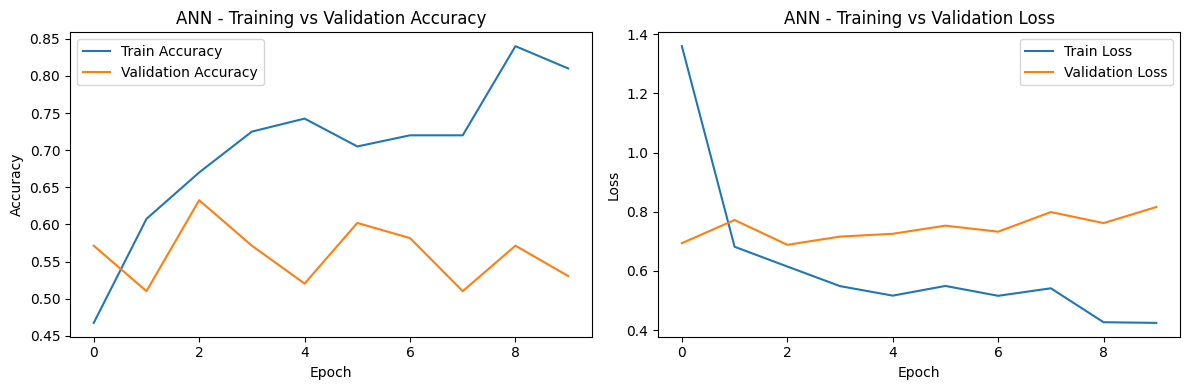

In [ ]:
# Build a simple ANN
ann_model = keras.Sequential([
    # Flatten the 2D image into 1D
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Show model summary
ann_model.summary()

# Train for 10 epochs
history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot training vs validation accuracy
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN - Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('ANN - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.5175 - loss: 0.7006 - val_accuracy: 0.5000 - val_loss: 0.6903
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.5575 - loss: 0.6809 - val_accuracy: 0.5816 - val_loss: 0.6763
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.5275 - loss: 0.6907 - val_accuracy: 0.5510 - val_loss: 0.6823
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - accuracy: 0.5775 - loss: 0.6693 - val_accuracy: 0.6327 - val_loss: 0.6613
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.6325 - loss: 0.6352 - val_accuracy: 0.6020 - val_loss: 0.6700
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.6600 - loss: 0.5961 - val_accuracy: 0.6122 - val_loss: 0.6888
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.6625 - loss: 0.6097 - val_accuracy: 0.6633 - val_loss: 0.6386
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.7025 - loss: 0.5648 - val_accuracy: 0.

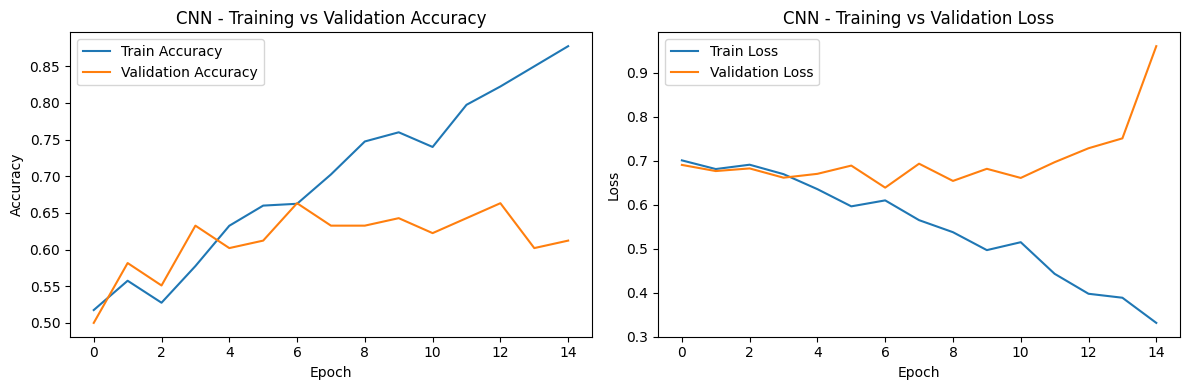

In [ ]:
cnn_model = keras.Sequential([
    # First Conv layer: 32 filters, 3x3 kernel
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv layer: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv layer: 64 filters with 3x3 kernel, followed by Max pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the CNN
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
cnn_model.summary()

# Train the CNN
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

# Plot training vs validation accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN - Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

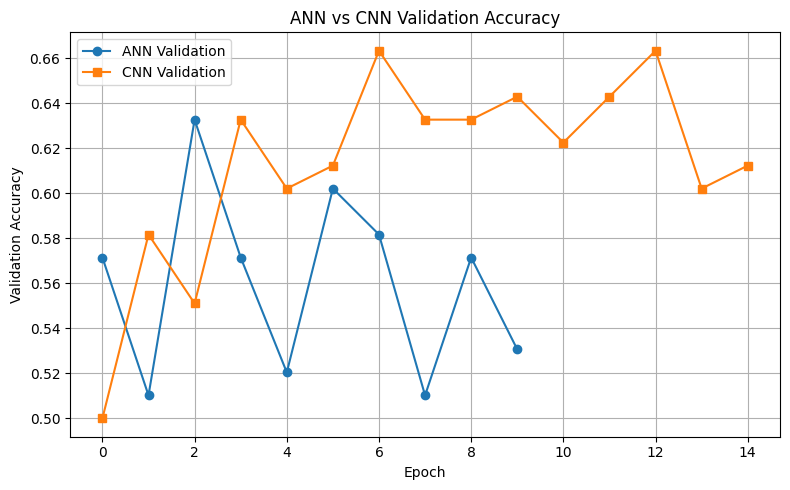

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('ANN vs CNN Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Data Augmentation Generator
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Final model with same architecture as improved_model
final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_model.summary()

history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)



Found 400 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 557ms/step - accuracy: 0.5150 - loss: 0.7104 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.5150 - loss: 0.6967 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.5025 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.5175 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.5775 - loss: 0.6904 - val_accuracy: 0.5612 - val_loss: 0.6904
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.5650 - loss: 0.6857 - val_accuracy: 0.5510 - val_loss: 0.6837
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 0.5700 - loss: 0.6831 - val_accuracy: 0.6122 - val_loss: 0.6748
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - accuracy: 0.5600 - loss: 0.6857 - val_accuracy: 0

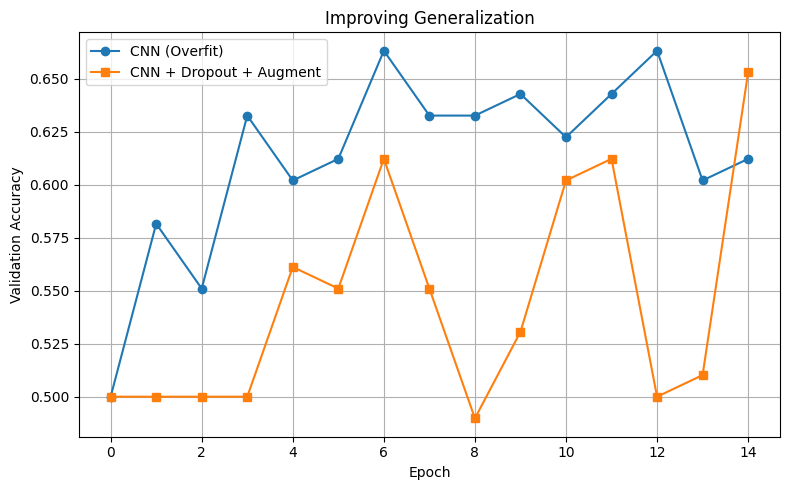

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Improving Generalization')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
🌭 HOT DOG! (confidence: 0.50)


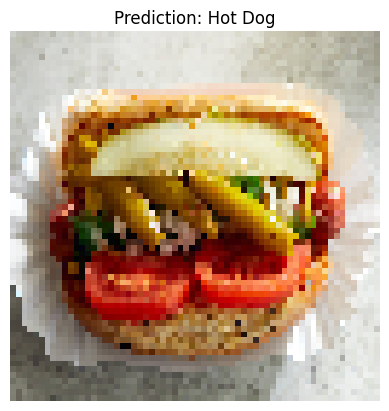

In [32]:
from tensorflow.keras.preprocessing import image
import requests
from io import BytesIO

def predict_image(img_url):
    response = requests.get(img_url)
    img = image.load_img(BytesIO(response.content), target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]

    if prediction > 0.5:
        print(f"🌭 HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"❌ NOT A HOT DOG! (confidence: {1-prediction:.2f})")

    # Show image
    plt.imshow(img)
    plt.title(f"Prediction: {'Hot Dog' if prediction > 0.5 else 'Not Hot Dog'}")
    plt.axis('off')
    plt.show()

# Test on a hot dog image
predict_image("https://static01.nyt.com/images/2022/07/27/dining/27Chicagodogrex/05Chicagodogrex-superJumbo.jpg")

